In [4]:
import numpy as np
import pandas as pd


class MCMCResult:
    r"""
    Classe che raccoglie i risultati di un'ottimizzazione o di un fitting MCMC.

    I possibili attributi includono:

    Attributes
    ----------
    residual : numpy.ndarray
        Array di residui (es. data - model) usando i migliori parametri trovati.
    params : dict or lmfit.Parameters
        Parametri finali best-fit.
    var_names : list
        Lista di nomi dei parametri variabili nell'ottimizzazione,
        nello stesso ordine di `init_vals` e `chain` (se presenti).
    covar : numpy.ndarray or None
        Matrice di covarianza dei parametri.
    chain : numpy.ndarray
        Campioni della catena MCMC, con dimensioni:
        (nwalkers, nsteps, nvarys) o simili a seconda dell’implementazione.
    init_vals : list
        Lista di valori iniziali dei parametri variabili (in ordine con `var_names`).
    aborted : bool
        Indica se il fitting è stato interrotto o abortito prima della fine.
    status : int
        Stato di terminazione dell'ottimizzazione (dipende dall'algoritmo sottostante).
    success : bool
        `True` se l'ottimizzazione si è conclusa senza errori, altrimenti `False`.
    errorbars : bool
        Indica se sono state stimate incertezze per i parametri variabili.
    message : str
        Messaggio sintetico sull'esito del fit.
    nfev : int
        Numero di valutazioni della funzione obiettivo (likelihood, chisq, ecc.).
    nvarys : int
        Numero di parametri variabili.
    ndata : int
        Numero di punti dati.
    nfree : int
        Gradi di libertà del fit = (ndata - nvarys).
    chisqr : float
        Valore di chi-quadro: \(\chi^2 = \sum_i (resid_i)^2\).
    redchi : float
        Chi-quadro ridotto: \(\chi^2_\nu = \chi^2 / (ndata - nvarys)\).
    aic : float
        Akaike Information Criterion: \( N \ln(\chi^2/N) + 2 * nvarys\).
    bic : float
        Bayesian Information Criterion: \( N \ln(\chi^2/N) + \ln(N) * nvarys\).

    Methods
    -------
    show_candidates(candidate_nmb='all')
        Mostra a schermo i parametri dei candidati (se esiste una lista `candidates`).
    calculate_statistics()
        Calcola statistiche standard (chisqr, redchi, aic, bic, ecc.).
    _repr_html_()
        Rappresentazione HTML (per Jupyter Notebook / IPython).
    """

    def __init__(self, **kwargs):
        """
        Inizializzazione della classe. Gli attributi possono essere passati
        direttamente come keyword arguments (ad esempio residual=resid_array,
        params=...).
        """
        for key, val in kwargs.items():
            setattr(self, key, val)

        # Calcola alcune statistiche di base appena la classe è creata
        # (opzionale: si può spostare in un metodo dedicato)
        self.calculate_statistics()

    @property
    def flatchain(self):
        """
        Ritorna una vista "flattened" (pandas.DataFrame) della catena MCMC
        se la catena è stata generata (ad esempio da emcee).

        Richiede che `pandas` sia installato e che l'attributo `chain` esista.
        """
        if not hasattr(self, "chain"):
            return None
        if not isinstance(self.chain, np.ndarray):
            return None

        if len(self.chain.shape) == 3:
            # Esempio: (nwalkers, nsteps, nvarys)
            nwalkers, nsteps, nvarys = self.chain.shape
            # Reshape in una tabella 2D => (nwalkers*nsteps, nvarys)
            flat = self.chain.reshape(-1, nvarys)
            return pd.DataFrame(flat, columns=self.var_names)
        elif len(self.chain.shape) == 2:
            # Esempio: (nsteps, nvarys) -> singola catena
            return pd.DataFrame(self.chain, columns=self.var_names)
        else:
            raise ValueError("Struttura della catena non riconosciuta.")

    def show_candidates(self, candidate_nmb="all"):
        """
        Mostra (stampa) i parametri dei candidati se è presente
        un attributo `candidates`.

        Parameters
        ----------
        candidate_nmb : int or 'all'
            Se 'all', mostra tutti i candidati.
            Se è un intero, mostra quel candidato specifico (1-based).
        """
        if hasattr(self, "candidates"):
            if candidate_nmb == "all":
                for i, candidate in enumerate(self.candidates):
                    print(f"\nCandidate #{i+1}, chisqr = {candidate.score:.3f}")
                    if hasattr(candidate, "params") and hasattr(
                        candidate.params, "pretty_print"
                    ):
                        candidate.params.pretty_print()
                    else:
                        print(candidate.params)
            else:
                if not (1 <= candidate_nmb <= len(self.candidates)):
                    raise ValueError(
                        f"'candidate_nmb' deve essere compreso tra 1 e {len(self.candidates)}"
                    )
                candidate = self.candidates[candidate_nmb - 1]
                print(f"\nCandidate #{candidate_nmb}, chisqr = {candidate.score:.3f}")
                if hasattr(candidate, "params") and hasattr(
                    candidate.params, "pretty_print"
                ):
                    candidate.params.pretty_print()
                else:
                    print(candidate.params)
        else:
            print("Nessun candidato registrato.")

    def calculate_statistics(self):
        """
        Calcola statistiche di base come chisq, redchi, aic, bic
        in base a `residual`, `ndata`, `nvarys` etc.

        Se alcuni attributi non sono definiti, vengono inizializzati a valori di default.
        """
        # Imposta default per ndata, nvarys, residual se mancanti
        self.residual = getattr(self, "residual", None)
        self.nfev = getattr(self, "nfev", 0)
        self.nvarys = getattr(self, "nvarys", 0)
        self.nfree = getattr(self, "nfree", None)  # se non presente, lo calcoliamo
        self.ndata = getattr(self, "ndata", None)

        # Determina chisqr, ndata e nfree
        if self.residual is not None and isinstance(self.residual, np.ndarray):
            self.chisqr = float((self.residual**2).sum())
            self.ndata = len(self.residual) if self.ndata is None else self.ndata
            self.nvarys = (
                len(self.var_names)
                if not self.nvarys and hasattr(self, "var_names")
                else self.nvarys
            )
            self.nfree = (
                self.ndata - self.nvarys
                if (self.nfree is None and self.ndata and self.nvarys)
                else self.nfree
            )
        else:
            # Se non abbiamo residual come array, impostiamo chisqr a zero per convenzione
            self.chisqr = 0.0
            if self.ndata is None:
                self.ndata = 1
            if self.nvarys is None:
                self.nvarys = 0
            if self.nfree is None:
                self.nfree = max(0, self.ndata - self.nvarys)

        # Calcolo redchi
        if self.nfree > 0:
            self.redchi = self.chisqr / self.nfree
        else:
            self.redchi = np.inf

        # Stima AIC e BIC
        # Protezione da log(0) => impediamo chisqr=0
        eps = 1e-250
        chisqr_valid = max(self.chisqr, eps * self.ndata)
        _neg2_log_likel = self.ndata * np.log(chisqr_valid / self.ndata)
        self.aic = _neg2_log_likel + 2 * self.nvarys
        # BIC
        if self.ndata > 0:
            self.bic = _neg2_log_likel + np.log(self.ndata) * self.nvarys
        else:
            self.bic = np.inf

    

    def __repr__(self):
        """
        Rappresentazione testuale compatta dell'oggetto, richiamata da `repr()`.
        """
        return (
            f"<MCMCResult: success={getattr(self, 'success', False)}, "
            f"chisqr={getattr(self, 'chisqr', 'N/A'):.4g}, "
            f"redchi={getattr(self, 'redchi', 'N/A'):.4g}, "
            f"ndata={getattr(self, 'ndata', 'N/A')}, "
            f"nvarys={getattr(self, 'nvarys', 'N/A')}>"
        )

    def __str__(self):
        """
        Rappresentazione testuale più estesa dell'oggetto, richiamata da `print()`.
        """
        lines = [
            "=== Fit Result ===",
            f"    success   = {getattr(self, 'success', False)}",
            f"    message   = {getattr(self, 'message', '')}",
            f"    ndata     = {getattr(self, 'ndata', 'N/A')}",
            f"    nvarys    = {getattr(self, 'nvarys', 'N/A')}",
            f"    chisqr    = {getattr(self, 'chisqr', 'N/A'):.4g}",
            f"    redchi    = {getattr(self, 'redchi', 'N/A'):.4g}",
            f"    aic       = {getattr(self, 'aic', 'N/A'):.4g}",
            f"    bic       = {getattr(self, 'bic', 'N/A'):.4g}",
        ]
        if hasattr(self, "params"):
            lines.append("    params:")
            if isinstance(self.params, dict):
                for k, v in self.params.items():
                    lines.append(f"        {k} = {v}")
            else:
                lines.append("        (Usare .pretty_print() se disponibile)")
        return "\n".join(lines)


In [5]:
from typing import Iterable, Union, Dict, Optional
import emcee
import numpy as np
import corner


class MCMC:
    """
    Classe wrapper di base per l'utilizzo dell'algoritmo MCMC (Markov Chain Monte Carlo)
    tramite la libreria `emcee`.

    Parameters
    ----------
    model : object
        Istanza di un oggetto modello che deve fornire le seguenti proprietà/metodi:
        - `free_parameters`: lista dei parametri liberi, ciascuno con `.value` e `.bounds` (tuple (min, max)).
        - `call(grid, *theta)`: metodo che, dati un grid e i valori dei parametri, restituisce l'output del modello.
        - `parameters_names`: lista dei nomi di tutti i parametri (sia liberi che non).
        - `parameters_keys`: chiavi identificative di tutti i parametri (sia liberi che non).
        - `parameters_values_dict`: dizionario dei parametri, con nome come chiave e valore come valore del parametro.
        - `n_dim`: dimensione del grid (es. 1D, 2D, ...).
        - `__getitem__(pname)`: per accedere a un parametro a partire dal suo nome (restituisce un oggetto con `.frozen`).

    **kwargs
        Ulteriori argomenti passati internamente a `emcee.EnsembleSampler`. Ad esempio:
        - `moves`
        - `backend`
        - etc.
    """

    def __init__(self, model, **kwargs) -> None:
        self._model = model
        self.emcee_kwargs = (
            kwargs  # Rinomino 'esembler_kwargs' in 'emcee_kwargs' per chiarezza.
        )

    @property
    def model(self):
        """
        Riferimento al modello associato a questa classe MCMC.

        Returns
        -------
        object
            Il modello utilizzato per la stima MCMC.
        """
        return self._model

    def logprior(self, theta: np.ndarray) -> float:
        """
        Calcola il log-prior per i parametri `theta`.

        Il prior è zero se tutti i parametri rientrano nei rispettivi bounds,
        altrimenti ritorna `-np.inf`.

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.

        Returns
        -------
        float
            Il valore della log-prior.
        """
        # Controlla se ogni parametro è all'interno dei suoi bounds
        for param, val in zip(self.model.free_parameters, theta):
            if val < param.bounds[0] or val > param.bounds[1]:
                return -np.inf
        return 0.0

    def loglike(
        self,
        theta: np.ndarray,
        xdata: Union[list, np.ndarray],
        ydata: Union[list, np.ndarray],
        yerr: Union[list, np.ndarray],
    ) -> float:
        """
        Calcola la log-likelihood dati i dati e il modello,
        assumendo errori gaussiani indipendenti.

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.
        xdata : array-like
            Dati indipendenti (es. valori di ascissa).
        ydata : array-like
            Dati osservati (es. valori di ordinata).
        yerr : array-like
            Incertezze (errore standard) associate ai dati osservati.

        Returns
        -------
        float
            Valore della log-likelihood.
        """
        # Calcolo del modello
        ymodel = self.model.call([xdata], *theta)
        # Residui e calcolo della likelihood
        residuals = ydata - ymodel
        ln = -0.5 * np.sum((residuals**2 / yerr**2) + np.log(2 * np.pi * yerr**2))
        return ln

    def log_probability(
        self,
        theta: np.ndarray,
        xdata: Union[list, np.ndarray],
        ydata: Union[list, np.ndarray],
        yerr: Union[list, np.ndarray],
    ) -> float:
        """
        Calcola la log-probability (somma di log-prior e log-likelihood).

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.
        xdata : array-like
            Dati indipendenti.
        ydata : array-like
            Dati osservati.
        yerr : array-like
            Incertezze (errore standard) associate ai dati osservati.

        Returns
        -------
        float
            Valore della log-probabilità (log-prior + log-likelihood).
        """
        lp = self.logprior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + self.loglike(theta, xdata, ydata, yerr)

    def _emcee_positions(
        self, theta0: np.ndarray, nwalkers: int, bounds: list, dispersion:float,
    ) -> np.ndarray:
        """
        Genera una matrice di posizioni iniziali per emcee con dispersione
        del 10% rispetto ai parametri iniziali. I punti fuori dai bound
        specificati vengono rigenerati.

        Parameters
        ----------
        theta0 : np.ndarray
            Posizione iniziale dei parametri, array di forma (ndim,).
        nwalkers : int
            Numero di walkers per emcee.
        bounds : list of tuple
            Lista di tuple (lower_bound, upper_bound) per ciascun parametro.

        Returns
        -------
        np.ndarray
            Array di forma (nwalkers, ndim) contenente le posizioni iniziali
            dei walkers.
        """
        ndim = len(theta0)
        pos = np.zeros((nwalkers, ndim))
        
        if dispersion < 0 or dispersion > 1:
            raise ValueError("Initial points dispersion must be > 0 and < 1")

        # Controllo che l'inizializzazione non sia fuori dai bound
        for i, point in enumerate(theta0):
            if not (bounds[i][0] < point < bounds[i][1]):
                raise ValueError(
                    f"Il valore iniziale per il parametro '{self.model.parameters_names[i]}' "
                    f"è fuori dal bound {bounds[i]}!"
                )

        def generate_valid_position() -> np.ndarray:
            while True:
                # Genera una posizione con dispersione casuale (10%)
                candidate = theta0 + dispersion * np.abs(theta0) * (
                    2 * np.random.rand(ndim) - 1
                )
                # Controlla se tutti i parametri rispettano i bound
                if all(
                    lower <= value <= upper
                    for value, (lower, upper) in zip(candidate, bounds)
                ):
                    return candidate

        # Popola l'array con posizioni valide per ciascun walker
        for i in range(nwalkers):
            pos[i] = generate_valid_position()

        return pos

    def _check_initial_state(
        self,
        theta0: Optional[Union[list, np.ndarray, Dict[str, float]]],
        grid: Union[list, np.ndarray],
        data: Union[list, np.ndarray],
    ) -> np.ndarray:
        """
        Verifica e prepara lo stato iniziale `theta0` in base a come viene fornito (lista, array, dict).
        Inoltre controlla la compatibilità tra dimensione dei dati e output del modello.

        Parameters
        ----------
        theta0 : list or np.ndarray or dict, optional
            Stima iniziale dei parametri. Se `None`, vengono usati i valori
            già presenti nel modello per i parametri liberi.
        grid : array-like
            Grid su cui valutare il modello (può essere monodimensionale o multidimensionale).
        data : array-like
            Valori osservati corrispondenti alla valutazione del modello su `grid`.

        Returns
        -------
        np.ndarray
            Array di valori iniziali (stima dei parametri) in formato numpy (ndim,).

        Raises
        ------
        TypeError
            Se `grid` non è un array-like o se `theta0` non è un tipo supportato (list, dict, np.ndarray).
        ValueError
            Se la dimensione del `grid` non corrisponde a quella attesa dal modello,
            o se la lunghezza di `theta0` non corrisponde al numero di parametri liberi,
            o se la dimensione dei dati non corrisponde alla dimensione dell'output del modello.
        """
        if not isinstance(grid, (list, np.ndarray)):
            raise TypeError(
                "`grid` deve essere una lista o un numpy array (es. [X], [X, Y, ...])."
            )
        if isinstance(grid, list):
            grid = np.array(grid)

        # Controllo dimensione `grid` e modello
        if np.shape(grid)[0] != self.model.n_dim:
            raise ValueError(
                f"La dimensione del grid ({grid.ndim}) non corrisponde "
                f"alla dimensione del modello ({self.model.n_dim})."
            )

        # Se theta0 è None, uso i valori del modello
        if theta0 is None:
            theta0 = [p.value for p in self.model.free_parameters]

        # Se theta0 è un dict
        if isinstance(theta0, dict):
            # Copio i parametri correnti del modello
            initial = {**self.model.parameters_values_dict}
            for pname, pval in theta0.items():
                param = self.model[pname]
                if param.frozen:
                    raise ValueError(
                        f"Il parametro '{pname}' è frozen. Fornire solo valori per parametri free."
                    )
                initial[pname] = pval
            # Ricostruisco array in ordine
            theta0 = np.array(
                [
                    initial[name]
                    for name in self.model.parameters_keys
                    if not self.model[name].frozen
                ]
            )
        elif isinstance(theta0, (list, np.ndarray)):
            theta0 = np.array(theta0, dtype=float)
        else:
            raise TypeError(
                "L'ipotesi iniziale (theta0) deve essere una lista, un dict o un numpy array."
            )

        # Verifico che sia veramente un np.ndarray
        assert isinstance(theta0, np.ndarray)

        # Check lunghezza theta0 = numero di parametri liberi
        if len(theta0) != len(self.model.free_parameters):
            raise ValueError(
                f"Il numero di valori iniziali ({len(theta0)}) non corrisponde "
                f"al numero di parametri liberi ({len(self.model.free_parameters)})."
            )

        # Verifica della compatibilità tra dati e output del modello
        model_output = self.model.call(grid, *theta0)
        if np.shape(model_output) != np.shape(data):
            raise ValueError(
                f"La dimensione dei dati {np.shape(data)} non corrisponde "
                f"alla dimensione dell'output del modello {np.shape(model_output)}."
            )

        return theta0

    def fit(
        self,
        grid: Union[list, np.ndarray],
        data: Union[list, np.ndarray],
        theta0: Optional[Union[list, np.ndarray, Dict[str, float]]] = None,
        error: Optional[Union[list, np.ndarray]] = None,
        nwalkers: int = 32,
        nsteps: int = 5000,
        discard: int = 100,
        thin: int = 15,
        dispersion:float|int = 0.1,
        **kwargs,
    ):
        """
        Esegue il fitting MCMC del modello sui dati forniti.

        Parameters
        ----------
        grid : array-like
            Grid (indipendente) su cui valutare il modello (es. asse x).
        data : array-like
            Dati osservati corrispondenti alla valutazione del modello su `grid`.
        theta0 : list or np.ndarray or dict, optional
            Stima iniziale dei parametri. Se `None`, vengono usati i valori
            già presenti nel modello per i parametri liberi.
        error : array-like, optional
            Incertezze (errore standard) sui dati osservati.
            Se `None`, si assume un errore costante (o lo si può gestire diversamente).
        nwalkers : int, optional
            Numero di walker da utilizzare nell'algoritmo MCMC (default=32).
        nsteps : int, optional
            Numero di passi da eseguire per ogni walker (default=5000).
        discard : int, optional
            Numero di step iniziali (burn-in) da scartare (default=100).
        thin : int, optional
            Frequenza di thinning; un valore di 15 significa prendere 1 campione ogni 15 (default=15).
        **kwargs : dict
            Argomenti aggiuntivi passati a `emcee.EnsembleSampler.run_mcmc`.

        Returns
        -------
        flat_samples : np.ndarray
            Array di campioni estratti dalla catena MCMC dopo il burn-in e il thinning.
        fig : matplotlib.figure.Figure
            Figura `corner` che mostra le distribuzioni a posteriori dei parametri.
        """
        
        self.emcee_kwargs.update(**kwargs)
        # Controlla lo stato iniziale e i dati
        theta0 = self._check_initial_state(theta0=theta0, grid=grid, data=data)

        # Genera posizioni iniziali per i walker
        init_positions = self._emcee_positions(
            dispersion = dispersion,
            theta0=theta0,
            nwalkers=nwalkers,
            bounds=[p.bounds for p in self.model if not p.frozen],
        )

        nwalkers, ndim = init_positions.shape

        # Inizializza il sampler di emcee
        sampler = emcee.EnsembleSampler(
            nwalkers,
            ndim,
            self.log_probability,
            args=(grid, data, error),
            **self.emcee_kwargs,
        )

        # Esecuzione MCMC vera e propria
        sampler.run_mcmc(init_positions, nsteps, progress=True, **kwargs)

        # Estrae i campioni (flattening delle catene dopo burn-in e thinning)
        # Ottieni la catena completa (senza scartare e senza thinning)
        chain = sampler.get_chain(discard=0, thin=1, flat=False)
        # Ottieni i campioni "flattened" dopo burn-in e thinning
        flat_samples = sampler.get_chain(discard=discard, thin=thin, flat=True)

        # Stima dei parametri "best fit" (qui usiamo la mediana come esempio)
        best_fit = np.median(flat_samples, axis=0)

        # Calcolo dei residui con i parametri best fit
        model_output = self.model.call(grid, *best_fit)
        # Ravel se i dati sono multidimensionali
        residual = (data - model_output).ravel()

        # Prepara i nomi dei parametri
        labels = self.model.parameters_names

        # Costruiamo un dizionario dei parametri best-fit
        best_params = dict(zip(labels, best_fit))

        # Creiamo la figura corner (opzionale, la conserviamo come attributo)
        fig = corner.corner(flat_samples, labels=labels)

        # Inizializziamo MCMCResult
        result = MCMCResult(
            chain=chain,  # catena MCMC completa
            var_names=labels,  # nomi dei parametri
            params=best_params,  # parametri best-fit
            residual=residual,  # residui data-model
            success=True,  # per semplicità, consideriamo riuscito
            message="MCMC sampling completed successfully",
            nfev=sampler.iteration * nwalkers,  # stima del numero di valutazioni
            ndata=data.size if hasattr(data, "size") else len(data),
            nvarys=len(theta0),
            corner_plot=fig,  # salviamo la figura come attributo extra
        )

        # (Facoltativo) Se preferisci, puoi assegnare la figura dopo la creazione
        # result.corner_plot = fig

        return result


In [3]:
from model import Model
import matplotlib.pyplot as plt

def line(x,a,b):
    return a*x + b

line_model = Model.wrap(line, grid_variables=["x"])
print(line_model)

MODEL NAME: SimpleModel 
FREE PARAMS: 2
GRID VARIABLES: ['x']
N-DIM: 1
------------------------------------------------------------
     NAME            VALUE      IS-FROZEN  BOUNDS              
------------------------------------------------------------
0    a               1.00       No         (-inf, inf)         
1    b               1.00       No         (-inf, inf)         



Text(0, 0.5, 'y')

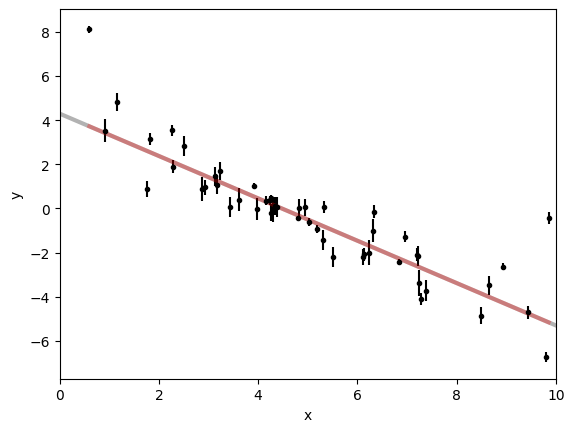

In [4]:


np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = line(x, m_true,b_true)
y_model = line_model(x, a=m_true, b=b_true)

y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, y_model, "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

In [5]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    #model = line_model.call([x], *theta[:-1])
    #log_f = theta[-1]
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [6]:
pos = np.array([-1.003,4.528,0.454]) + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
sampler.run_mcmc(pos, 5000, progress=True)


100%|██████████| 5000/5000 [00:01<00:00, 2502.80it/s]


State([[-0.97510039  4.36782527 -0.81605491]
 [-1.00601678  4.53260885 -0.83056728]
 [-0.93720894  4.17938317 -0.59033622]
 [-0.97531722  4.33909642 -0.94403177]
 [-1.02843595  4.58418601 -0.7425016 ]
 [-0.98223728  4.46479341 -0.92021177]
 [-1.04021281  4.67999111 -0.61881   ]
 [-1.09903011  4.99589969 -1.01713356]
 [-0.98506927  4.35514345 -0.83218987]
 [-1.08410398  4.9536327  -0.80589734]
 [-0.89350028  4.0577179  -0.83305118]
 [-0.90012021  4.17058709 -0.53366821]
 [-0.94096627  4.1869666  -0.99341455]
 [-0.96997551  4.39642426 -0.77344701]
 [-1.17169827  5.23268465 -0.90377596]
 [-0.95282045  4.3255526  -0.62270333]
 [-0.99906624  4.53237367 -0.7575723 ]
 [-0.96521987  4.38259859 -0.77109266]
 [-1.11843496  4.99351218 -0.91155153]
 [-1.19332932  5.37875954 -0.81625816]
 [-1.05994494  4.77775148 -0.71913327]
 [-1.01817051  4.60896984 -0.51209248]
 [-1.03159293  4.67263191 -0.70591701]
 [-1.0835509   4.90955135 -0.78323465]
 [-0.87782327  3.97027209 -0.29518059]
 [-0.96783639  4.35

(10432, 3)


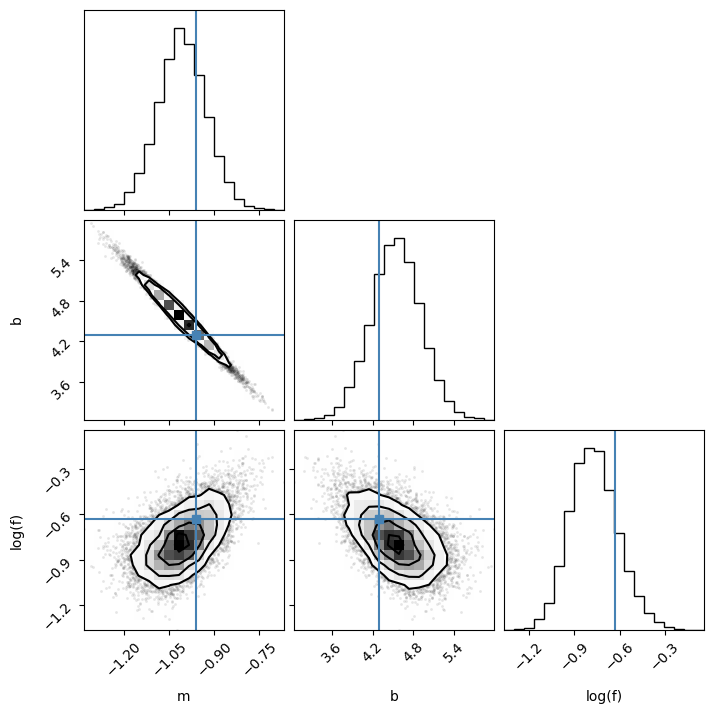

In [7]:
import corner
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)
labels = ["m", "b", "log(f)"]

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)


100%|██████████| 5000/5000 [00:02<00:00, 1840.41it/s]


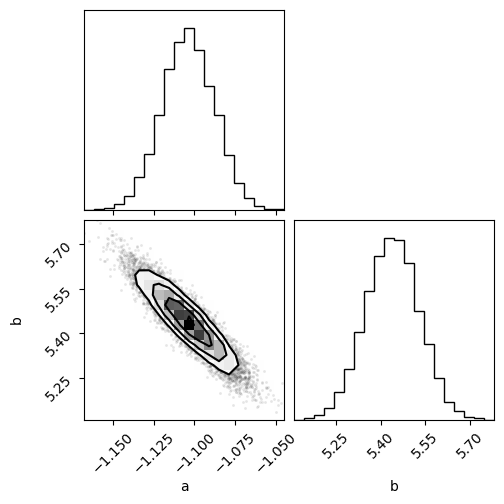

In [8]:
wrapper = MCMC(line_model)

result = wrapper.fit(grid = np.array([x]),
            data = y,
            error = yerr,
            theta0 = None,
            nwalkers=32
            #ndim=2
            )

In [9]:
print(result)

=== Fit Result ===
    success   = True
    message   = MCMC sampling completed successfully
    ndata     = 50
    nvarys    = 2
    chisqr    = 77.62
    redchi    = 1.617
    aic       = 25.99
    bic       = 29.81
    params:
        a = -1.1038391713858724
        b = 5.439584302032912


In [13]:
import numpy as np
from model import Model

def line(x, a, b):
    return a * x + b

def gaussian(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))

gaus = Model.wrap(gaussian, grid_variables=['x'], name = 'Gaussian')
line1 = Model.wrap(line, grid_variables=['x'], name='line')

cmodel = (gaus.copy() + gaus.copy()) + line1.copy()

cmodel.set_parameters_values(
    mu_0 =5.2,
    sigma_1 = 1.2,
    A_1 = 10,
    a_2 = 1.2,
    sigma_0 = .3,
    A_0 = 13.4,
    mu_1 = 2.5,
    b_2 = 0.01
)
print(cmodel)
cmodel.print_tree()

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Gaussian', 'Gaussian', 'line']
GRID VARIABLES: ['x']
LOGIC: ((Gaussian [0] + Gaussian [1]) + line [2])
FREE PARAMS: 8
------------------------------------------------------------
     NAME            VALUE      IS-FROZEN  BOUNDS               
------------------------------------------------------------
0    mu_0            5.20       No         (-inf, inf)         
1    sigma_0         0.30       No         (-inf, inf)         
2    A_0             13.40      No         (-inf, inf)         
3    mu_1            2.50       No         (-inf, inf)         
4    sigma_1         1.20       No         (-inf, inf)         
5    A_1             10.00      No         (-inf, inf)         
6    a_2             1.20       No         (-inf, inf)         
7    b_2             0.01       No         (-inf, inf)         

Composite(op='+')
    |-- Composite(op='+')
    |   |-- Gaussian
    |   `-- Gaussian
    `-- line


{'mu_0': 5.2, 'sigma_0': 0.3, 'A_0': 13.4, 'mu_1': 2.5, 'sigma_1': 1.2, 'A_1': 10}
{'a': 1.2, 'b': 0.01}


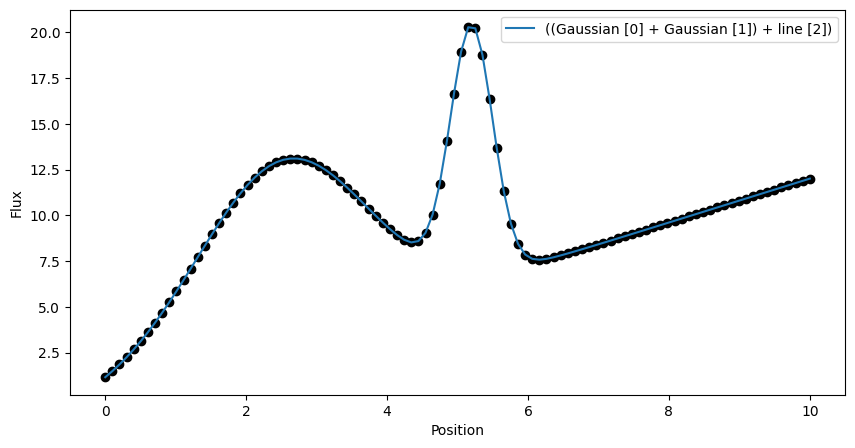

In [14]:
import matplotlib.pyplot as plt
X = np.linspace(0, 10, 100)
y = cmodel(X)# + np.random.normal(0.0, 1, X.shape)
# Plot the data with the best-fit model
plt.figure(figsize=(10, 5))
#plt.plot(X, -line([X]), linestyle="--", label=line.name)
#plt.plot(X, gaus([X]), linestyle="--", label=gaus.name)
#plt.plot(X, gaus([X]), linestyle="--", label=gaus.name)
plt.plot(X, y, "ko")
plt.plot(X, cmodel.call([X], *cmodel.parameters_values), label=cmodel.composite_structure())
plt.legend()
plt.xlabel("Position")
plt.ylabel("Flux")
plt.show()


In [15]:
opt = MCMC(cmodel)

result = opt.fit(grid = np.array([X]),
                 data = y,
                 error = y/100,
                 )

NameError: name 'MCMC' is not defined

In [8]:
print(result)

=== Fit Result ===
    success   = True
    message   = MCMC sampling completed successfully
    ndata     = 100
    nvarys    = 8
    chisqr    = 1.814e-05
    redchi    = 1.971e-07
    aic       = -1536
    bic       = -1515
    params:
        mu = 2.4999889176721557
        sigma = 1.199985113017409
        A = 9.999781970455636
        a = 0.19994434048677173
        b = 1.0002949262483818
